# Importacion de librerias y carga del dataset

In [24]:
import numpy as np

# Librerias para graficar
import matplotlib.pyplot as pyplot
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy import optimize

#Para separa el Dataset 20% y 80% para diferentes pruebas
from sklearn.model_selection import train_test_split

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

In [25]:
# Cargar datos
data = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


# Preprocesamiento

In [26]:
print('\nDATOS VACIOS')
print(pd.isnull(data).sum())


DATOS VACIOS
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole        

In [27]:
data.drop(["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"], axis=1, inplace=True)
data

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


In [28]:
# Convertir columna objetivo a binaria
data["Attrition"] = data["Attrition"].map({"Yes": 1, "No": 0})
# Convertir variables categóricas a dummies
data = pd.get_dummies(data, drop_first=True)
data


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,41,4,2,4,...,True,False,False,False,False,False,False,True,False,False
1466,39,0,613,6,1,4,42,2,3,1,...,False,False,False,False,False,False,False,True,False,False
1467,27,0,155,4,3,2,87,4,2,2,...,False,False,True,False,False,False,False,True,False,True
1468,49,0,1023,2,3,4,63,2,2,2,...,False,False,False,False,False,True,False,True,False,False


# 4. Definir X (features) e y (objetivo)

In [29]:
X = data.drop("Attrition", axis=1).values
y = data["Attrition"].values

In [30]:
# Normalizar datos
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [31]:
# Agregar columna de 1s para el término independiente
X = np.insert(X, 0, 1, axis=1)

In [32]:
# Dividiendo los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

m = y_train.size


# Mostramos los datos que seran para el entrenamiento
print("Datos de X_train:")
print(X_train)
print("Datos de y_train:")
print(y_train)

# Mostramos la cantidad de ejemplos que tienen X_train y y_train
print('-' * 80)
print("El 80% de ejemplos que seran para el entrenamiento son: {:.0f}".format(len(X_train)))
print("El 20% de ejemplos que seran para el test son: {:.0f}".format(len(X_test)))
     

Datos de X_train:
[[ 1.          1.10336151  1.04745611 ... -0.91892141 -0.68556546
  -0.62824112]
 [ 1.         -1.63418477 -0.5168574  ...  1.08823234 -0.68556546
  -0.62824112]
 [ 1.          0.99385966 -0.98292862 ...  1.08823234 -0.68556546
  -0.62824112]
 ...
 [ 1.         -1.63418477 -1.45147894 ...  1.08823234 -0.68556546
  -0.62824112]
 [ 1.         -0.10115885 -0.92343017 ...  1.08823234 -0.68556546
   1.59174553]
 [ 1.          0.2273467  -0.09045182 ... -0.91892141 -0.68556546
  -0.62824112]]
Datos de y_train:
[0 0 0 ... 0 0 0]
--------------------------------------------------------------------------------
El 80% de ejemplos que seran para el entrenamiento son: 1176
El 20% de ejemplos que seran para el test son: 294


In [33]:
# Obtener las dimensiones del array
m, n = X_train.shape

print(f"m (número de filas): {m}")
print(f"n (número de columnas): {n}")

m (número de filas): 1176
n (número de columnas): 45


In [34]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

In [35]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    epsilon = 1e-15
    J = (1/m) * np.sum(-y * np.log(h + epsilon) - (1-y) * np.log(1 - h + epsilon))

    return J

In [36]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

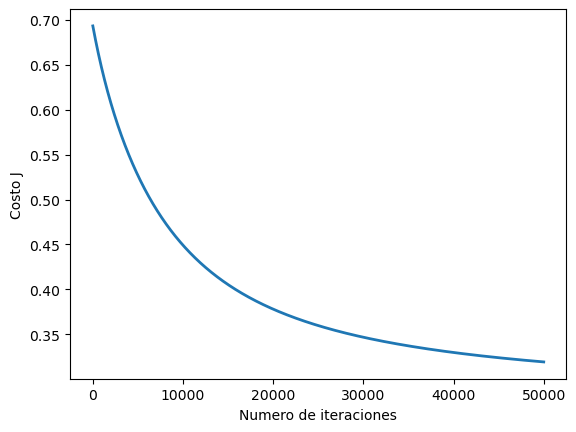

theta calculado por el descenso por el gradiente: [-1.71243929 -0.22775331 -0.11773133  0.19242041  0.01059118 -0.24968709
 -0.01942632 -0.23396796 -0.05031384 -0.22737186 -0.04529887  0.01590125
  0.21576876 -0.04806408  0.02575763 -0.1483124  -0.17681804 -0.13636739
 -0.07800871 -0.16806212 -0.04423047 -0.12526091  0.17531422 -0.168331
  0.23783602  0.0236875  -0.09436167  0.07381848 -0.01579836  0.03371487
 -0.06865125 -0.098336    0.07700445  0.06761627  0.06698436  0.22921315
  0.00784394 -0.07567555 -0.08576502 -0.06959176  0.00356831  0.169241
 -0.04301082  0.19398345  0.48016121]


In [56]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.0003
num_iters = 50000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X_train.shape[1])
theta, J_history = descensoGradiente(theta, X_train, y_train, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.show()

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

In [57]:
print(f"Con un costo de: { J_history[-1]} ")

Con un costo de: 0.31935246157908953 


In [58]:
def predict(theta, X):
    return sigmoid(X.dot(theta.T)) >= 0.5

p = predict(theta, X_test)  # Asumiendo X_test con bias
print('Precisión en test: {:.2f}%'.format(np.mean(p == y_test) * 100))

Precisión en test: 87.41%
